In [1]:
'''
author: Yike Xie
data: 4/26/2025
content: Shuffle hyperspectral and bootstrap 1000 times
'''

'\nauthor: Yike Xie\ndata: 4/26/2025\ncontent: Shuffle hyperspectral and bootstrap 1000 times\n'

In [2]:
import os
import sys
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns

import scanpy as sc
import anndata
import pickle

In [6]:
def sig_dataset(feas_fn, data_fn):
    print('load features')
    with open(feas_fn, 'rb') as f:
        features = pd.read_pickle(f)
    
    print('load dataset')
    adata = sc.read_h5ad(data_fn)
    sc.pp.normalize_total(adata, target_sum=1e6)

    print('filter genes')
    sc.pp.filter_genes(adata, min_cells=10)

    print('Add features to adata')
    for col in features.columns:
        adata.obs[col] = features.loc[adata.obs_names][col]

    return adata

# Load data

In [7]:
feas_fn = '/home/yike/phd/cancer_cells_img_seq/figures/combine_features.pkl'
data_fn = '/home/yike/phd/cancer_cells_img_seq/data/combine_gene.h5ad'
adata = sig_dataset(feas_fn, data_fn)

# add average optical intensity to adata
df = pd.DataFrame(index=adata.obs_names, columns=adata.obs['wavelengths'].iloc[0])
for i in df.index:
    df.loc[i] = adata.obs['spectra'].loc[i] / adata.obs['area'].loc[i]
    
for col in df.columns:
    adata.obs['{}_{}'.format(col[0], col[1])] = df.loc[adata.obs_names][col]
    
adata.obs['C4_C2'] = df[df.columns[3]] / df[df.columns[1]]

load features
load dataset
filter genes
Add features to adata


In [39]:
## divide live and dead cells according to the fraction o mitochondrial reads
live_cells = adata.obs[adata.obs['pct_counts_mt'] < 25].index
dead_cells = adata.obs[adata.obs['pct_counts_mt'] > 25].index

# create dataset only having cells with low percentage of mitochondrial reads
adata_live = adata[live_cells, :].copy()

In [10]:
save_path = '/home/yike/phd/cancer_cells_img_seq/figures/seg_rings/' 
ring_int_df =  pd.read_csv(save_path + 'ring_int_df.tsv', sep='\t', index_col=0)
######## key parameter
bright_ring_cells = ring_int_df[ring_int_df['Log2FC'] > 0.4].index.tolist() # 60 cells
########
dim_ring_cells = list(set(adata.obs_names) - set(bright_ring_cells))

adata.obs['Ring'] = 'Ringed'
adata.obs.loc[dim_ring_cells, 'Ring'] = 'Unringed'

In [15]:
from scipy.stats import mannwhitneyu  # or ttest_ind if normal
from tqdm import tqdm

# Step 1: Observed test
obs_ringed = adata.obs[adata.obs['Ring'] == 'Ringed']['pct_counts_mt']
obs_unringed = adata.obs[adata.obs['Ring'] == 'Unringed']['pct_counts_mt']

# Use Mann-Whitney U for robustness
stat_obs, pval_obs = mannwhitneyu(obs_ringed, obs_unringed, alternative='two-sided')

print(f"Observed Mann-Whitney U p-value: {pval_obs:.4f}")

# Step 2: Run permutation test
n_iter = 1000
pvals = []

for _ in tqdm(range(n_iter), desc="Permuting Ring labels"):
    shuffled = adata.obs['Ring'].sample(frac=1, replace=False).values
    ringed_idx = shuffled == 'Ringed'
    unringed_idx = shuffled == 'Unringed'
    
    ringed_vals = adata.obs['pct_counts_mt'].values[ringed_idx]
    unringed_vals = adata.obs['pct_counts_mt'].values[unringed_idx]
    
    # Compute p-value for this shuffle
    try:
        _, pval = mannwhitneyu(ringed_vals, unringed_vals, alternative='two-sided')
        pvals.append(pval)
    except:
        pvals.append(1.0)  # fallback for rare edge cases

# Step 3: Count how many permuted p-values are more significant than observed
pvals = np.array(pvals)
n_more_significant = np.sum(pvals <= pval_obs)

print(f"\nOut of {n_iter} permutations, {n_more_significant} had p-values ≤ observed ({pval_obs:.4f})")
print(f"Empirical significance level: {n_more_significant / n_iter:.4f}")

Observed Mann-Whitney U p-value: 0.0002


Permuting Ring labels: 100%|█████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 2208.53it/s]


Out of 1000 permutations, 0 had p-values ≤ observed (0.0002)
Empirical significance level: 0.0000


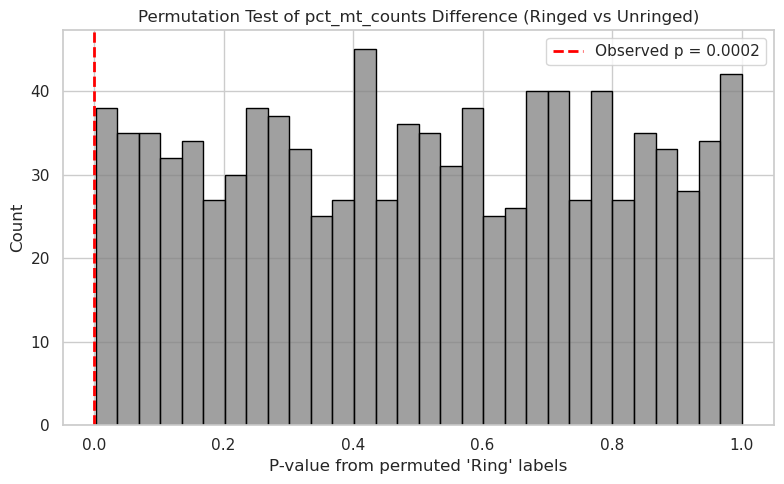

In [19]:
# Set style
sns.set(style="whitegrid")

# Plot histogram of permuted p-values
plt.figure(figsize=(8, 5))
sns.histplot(pvals, bins=30, kde=False, color='gray', edgecolor='black')

# Add a vertical line for observed p-value
plt.axvline(pval_obs, color='red', linestyle='--', linewidth=2, label=f'Observed p = {pval_obs:.4f}')

# Add labels and legend
plt.xlabel("P-value from permuted 'Ring' labels")
plt.ylabel("Count")
plt.title("Permutation Test of pct_mt_counts Difference (Ringed vs Unringed)")
plt.legend()

plt.tight_layout()
plt.savefig('/home/yike/phd/cancer_cells_img_seq/docs/manuscripts/Genome_research_202409/2nd_review/' + '1000_shuffle_ring_cells.png',
           dpi=300, bbox_inches='tight')


In [33]:
def get_correlation(adata_s, feas):
    #corr = dsim.correlation.correlate_features_phenotypes(feas, fillna=0)##
    exp = adata_s.X.T
    phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)

    x = exp #(39466, 10)
    if not isinstance(x, np.ndarray):
        x = x.toarray()  # convert sparse matrix to dense

    y = phe.values.T #(2, 10)

    from scipy.stats import rankdata

    xw = np.zeros_like(x, float)
    for ii, xi in enumerate(x):
        xw[ii] = rankdata(xi, method='average')
        
    yw = np.zeros_like(y, float)
    for ii, yi in enumerate(y):
        yw[ii] = rankdata(yi, method='average')

    xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
    yw = ((yw.T - yw.mean(axis=1)) / yw.std(axis=1)).T
    n = xw.shape[1]
    r = np.dot(xw, yw.T) / n

    corr = pd.DataFrame(
                    data=r,
                    index=adata_s.var_names,
                    columns=phe.columns,
                    dtype=float)

    return corr

In [21]:
tca_genes = [
    'IDH2', 'MDH2', 'SDHA', 'CS', 'MPC1', 'SDHC', 'SUCLG1', 'ME1', 'SDHB',
    'IDH3G', 'IDH3B', 'MPC2', 'ACO2', 'MDH1', 'DLD', 'OGDH', 'SDHD', 'PDHB', 'DLAT'
]

nucleotide_genes = [
    'NME1', 'CMPK1', 'UPP1', 'RRM2', 'UCK2', 'UCKL1', 'TK1',
    'RRM1', 'UCK1', 'UNG', 'RRM2B'
]


In [55]:
n_iter = 1000
tca_diffs = []
nuc_diffs = []

# Store original as well
orig_corr = get_correlation(adata_live, ['343_451'])
all_genes = orig_corr.index.tolist()

def compute_gene_set_diff(corr_df, gene_list, feature='343_451'):
    gene_list = [g for g in gene_list if g in corr_df.index]
    all_corr = np.abs(corr_df[feature])
    mean_gene_corr = np.mean(all_corr.loc[gene_list])
    return mean_gene_corr - all_corr

# Original observed differences
tca_obs_diff = compute_gene_set_diff(orig_corr, tca_genes, feature='343_451')
nuc_obs_diff = compute_gene_set_diff(orig_corr, nucleotide_genes, feature='343_451')

# Permutations
for _ in tqdm(range(n_iter), desc="Permuting 343_451"):
    shuffled = adata_live.obs['343_451'].sample(frac=1).values
    adata_live_tmp = adata_live.copy()
    adata_live_tmp.obs['343_451_shuffled'] = shuffled
    corr = get_correlation(adata_live_tmp, ['343_451_shuffled'])

    tca_diffs.append(compute_gene_set_diff(corr, tca_genes, feature='343_451_shuffled'))
    nuc_diffs.append(compute_gene_set_diff(corr, nucleotide_genes, feature='343_451_shuffled'))

/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:   0%|                                                                          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipy

/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:   1%|▊                                                                | 13/1000 [00:07<10:03,  1.63it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:   1%|▉                                                                | 14/1000 [00:08<10:03,  1.63it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .

Permuting 343_451:   3%|█▋                                                               | 26/1000 [00:15<09:54,  1.64it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:   3%|█▊                                                               | 27/1000 [00:16<09:55,  1.63it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `

Permuting 343_451:   4%|██▌                                                              | 39/1000 [00:23<09:50,  1.63it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:   4%|██▌                                                              | 40/1000 [00:24<09:49,  1.63it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `

Permuting 343_451:   5%|███▍                                                             | 52/1000 [00:31<09:36,  1.64it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:   5%|███▍                                                             | 53/1000 [00:32<09:33,  1.65it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `

...

Permuting 343_451:  94%|███████████████████████████████████████████████████████████▉    | 936/1000 [09:46<00:40,  1.56it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:  94%|███████████████████████████████████████████████████████████▉    | 937/1000 [09:47<00:39,  1.58it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `

Permuting 343_451:  95%|████████████████████████████████████████████████████████████▋   | 949/1000 [09:54<00:32,  1.59it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:  95%|████████████████████████████████████████████████████████████▊   | 950/1000 [09:55<00:31,  1.60it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `

Permuting 343_451:  96%|█████████████████████████████████████████████████████████████▌  | 962/1000 [10:03<00:24,  1.53it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:  96%|█████████████████████████████████████████████████████████████▋  | 963/1000 [10:03<00:24,  1.54it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `

Permuting 343_451:  98%|██████████████████████████████████████████████████████████████▍ | 975/1000 [10:11<00:16,  1.52it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:  98%|██████████████████████████████████████████████████████████████▍ | 976/1000 [10:12<00:15,  1.55it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `

Permuting 343_451:  99%|███████████████████████████████████████████████████████████████▏| 988/1000 [10:19<00:07,  1.55it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:  99%|███████████████████████████████████████████████████████████████▎| 989/1000 [10:20<00:07,  1.48it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `

TypeError: unsupported format string passed to Series.__format__

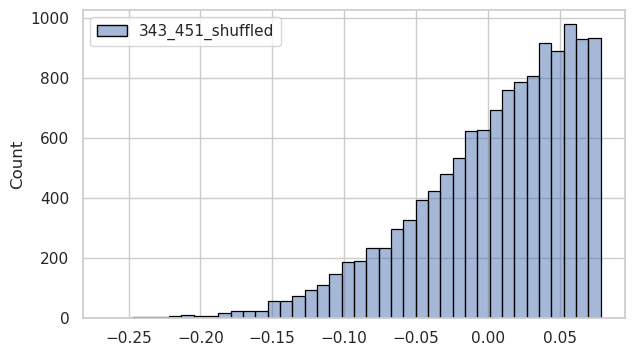

In [56]:
def plot_perm_test(dist, obs, title, path, fn):
    plt.figure(figsize=(7, 4))
    sns.histplot(dist, bins=40, color="lightgray", edgecolor="black")
    plt.axvline(obs, color='red', linestyle='--', label=f'Observed = {obs:.4f}')
    plt.xlabel("Mean correlation difference (gene set - others)")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(path, fn), dpi=300, bbox_inches='tight')

path = '/home/yike/phd/cancer_cells_img_seq/docs/manuscripts/Genome_research_202409/2nd_review/'
plot_perm_test(tca_diffs, tca_obs_diff, "TCA Cycle Gene Correlation Enrichment", 
               path=path, fn='1000_shuffle_C4_TCA_diff.png')
plot_perm_test(nuc_diffs, nuc_obs_diff, "Nucleotide Gene Correlation Enrichment",
               path=path, fn='1000_shuffle_C4_nuc_diff.png')


In [53]:
n_iter = 1000
tca_pvals = []
nuc_pvals = []

# Store original as well
orig_corr = get_correlation(adata_live, ['343_451'])
all_genes = orig_corr.index.tolist()

from scipy.stats import ks_2samp

def compute_gene_set_ks_pval(corr_df, gene_list, feature='343_451'):
    # Filter only genes that exist in correlation table
    gene_list = [g for g in gene_list if g in corr_df.index]
    
    # Get correlation values for all genes and the gene list
    all_corr = corr_df[feature].dropna()
    gene_list_corr = all_corr.loc[gene_list]
    
    # KS test (two-sided by default)
    stat, pval = ks_2samp(gene_list_corr, all_corr)
    return pval

# Observed p-values
tca_obs_pval = compute_gene_set_ks_pval(orig_corr, tca_genes, feature='343_451')
nuc_obs_pval = compute_gene_set_ks_pval(orig_corr, nucleotide_genes, feature='343_451')

# Permutations
for _ in tqdm(range(n_iter), desc="Permuting 343_451"):
    shuffled = adata_live.obs['343_451'].sample(frac=1).values
    adata_live_tmp = adata_live.copy()
    adata_live_tmp.obs['343_451_shuffled'] = shuffled
    corr = get_correlation(adata_live_tmp, ['343_451_shuffled'])

    tca_pvals.append(compute_gene_set_ks_pval(corr, tca_genes, feature='343_451_shuffled'))
    nuc_pvals.append(compute_gene_set_ks_pval(corr, nucleotide_genes, feature='343_451_shuffled'))

/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:   0%|                                                                          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipy

/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:   1%|▊                                                                | 13/1000 [00:07<09:41,  1.70it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:   1%|▉                                                                | 14/1000 [00:08<09:41,  1.70it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .

Permuting 343_451:   3%|█▋                                                               | 26/1000 [00:15<10:04,  1.61it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:   3%|█▊                                                               | 27/1000 [00:16<10:48,  1.50it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `

Permuting 343_451:   4%|██▌                                                              | 39/1000 [00:23<09:42,  1.65it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:   4%|██▌                                                              | 40/1000 [00:24<09:45,  1.64it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `

Permuting 343_451:   5%|███▍                                                             | 52/1000 [00:31<09:38,  1.64it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:   5%|███▍                                                             | 53/1000 [00:32<09:43,  1.62it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `

...

Permuting 343_451:  94%|███████████████████████████████████████████████████████████▉    | 936/1000 [09:46<00:39,  1.61it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:  94%|███████████████████████████████████████████████████████████▉    | 937/1000 [09:46<00:39,  1.61it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `

Permuting 343_451:  95%|████████████████████████████████████████████████████████████▋   | 949/1000 [09:54<00:31,  1.61it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:  95%|████████████████████████████████████████████████████████████▊   | 950/1000 [09:55<00:31,  1.61it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `

Permuting 343_451:  96%|█████████████████████████████████████████████████████████████▌  | 962/1000 [10:02<00:23,  1.61it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:  96%|█████████████████████████████████████████████████████████████▋  | 963/1000 [10:03<00:23,  1.61it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `

Permuting 343_451:  98%|██████████████████████████████████████████████████████████████▍ | 975/1000 [10:10<00:15,  1.61it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:  98%|██████████████████████████████████████████████████████████████▍ | 976/1000 [10:11<00:14,  1.61it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `

Permuting 343_451:  99%|███████████████████████████████████████████████████████████████▏| 988/1000 [10:18<00:07,  1.62it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phe = adata_s.obs[feas].fillna(0).infer_objects(copy=False)
/tmp/ipykernel_31787/368724604.py:22: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
Permuting 343_451:  99%|███████████████████████████████████████████████████████████████▎| 989/1000 [10:19<00:06,  1.62it/s]/tmp/ipykernel_31787/368724604.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `

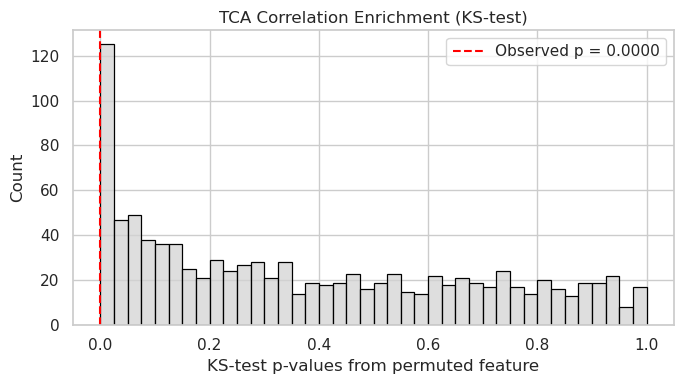

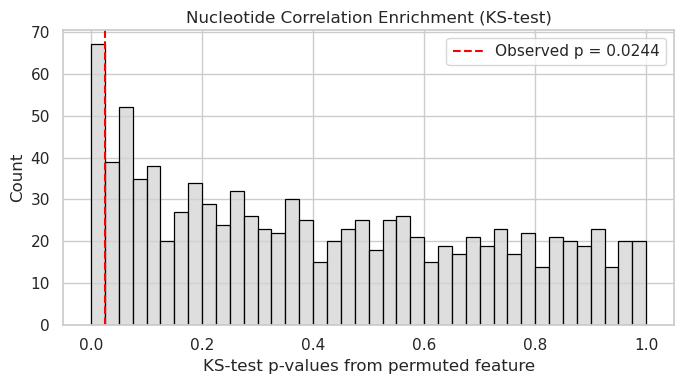

In [54]:
def plot_perm_pval_dist(pvals, obs_pval, title, path, fn):
    plt.figure(figsize=(7, 4))
    sns.histplot(pvals, bins=40, color="lightgray", edgecolor="black")
    plt.axvline(obs_pval, color='red', linestyle='--', label=f'Observed p = {obs_pval:.4f}')
    plt.xlabel("KS-test p-values from permuted feature")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(path, fn), dpi=300, bbox_inches='tight')

path = '/home/yike/phd/cancer_cells_img_seq/docs/manuscripts/Genome_research_202409/2nd_review/'
plot_perm_pval_dist(tca_pvals, tca_obs_pval, "TCA Correlation Enrichment (KS-test)", 
                    path=path, fn='1000_shuffle_C4_TCA_ks.png')
plot_perm_pval_dist(nuc_pvals, nuc_obs_pval, "Nucleotide Correlation Enrichment (KS-test)",
                    path=path, fn='1000_shuffle_C4_nuc_ks.png')


In [52]:
1

1